In [5]:
# Import niezbędnych bibliotek
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
 # Ustawienie ziarna losowości dla powtarzalności wyników
np.random.seed(42)

In [9]:
 # Generowanie syntetycznych danych dla 500 mieszkań
liczba_mieszkan = 500

In [10]:
 # Tworzenie słownika z danymi
dane = {
     # Metraż mieszkania: losowe wartości od 25 do 150 m²
    'Metraz': np.random.uniform(25, 150, liczba_mieszkan),

    # Liczba pokoi: od 1 do 5 pokoi (wartości całkowite)
    'Liczba_pokoi': np.random.randint(1, 6, liczba_mieszkan),

    # Wiek budynku: od 0 (nowy) do 50 lat
    'Wiek_budynku': np.random.uniform(0, 50, liczba_mieszkan),

    # Odległość od centrum: od 0.5 do 20 km
    'Odleglosc_od_centrum': np.random.uniform(0.5, 20, liczba_mieszkan)
  }

In [11]:
# Tworzenie DataFrame z pandas
df = pd.DataFrame(dane)

In [30]:
# Generowanie ceny na podstawie cech mieszkania
# Cena zależy od: metrażu (+), liczby pokoi (+), wieku (-), odległości od centrum (-)
df['Cena'] = (
    df['Metraz'] * 5000 +                      # Każdy m2 dodaje 5000 zł
    df['Liczba_pokoi'] * 30000 +               # Każdy pokój dodaje 30000 zł
    -df['Wiek_budynku'] * 2000 +               # Każdy rok wieku obniża o 2000 zł
    -df['Odleglosc_od_centrum'] * 8000 +       # Każdy km od centrum obniża o 8000 zł
    np.random.normal(0, 50000, liczba_mieszkan) # Dodanie losowego szumu
)

In [31]:
df.head()

,Metraz,Liczba_pokoi,Wiek_budynku,Odleglosc_od_centrum,Cena
0,71.817515,1,16.793293,9.204189,338185.822758
1,143.839288,1,41.255367,17.352215,567069.643670
2,116.499243,1,18.152961,11.383735,479817.318024
3,99.832311,5,1.711406,11.028164,618613.286627
4,44.502330,4,41.532725,1.166661,196550.200649


In [32]:
df.shape

(500, 5)

In [33]:
# Wyświetlenie podstawowych statystyk
print("Podstawowe statystyki zbioru danych:")
print(df.describe().round(2))
print("\n")

Podstawowe statystyki zbioru danych:
       Metraz  Liczba_pokoi  Wiek_budynku  Odleglosc_od_centrum       Cena
count  500.00        500.00        500.00                500.00     500.00
mean    87.32          2.96         25.40                 10.11  395601.53
std     37.34          1.44         14.47                  5.52  199278.26
min     25.63          1.00          0.01                  0.51  -36044.71
25%     55.16          2.00         13.14                  5.23  234692.87
50%     89.15          3.00         25.96                 10.32  395044.21
75%    119.52          4.00         37.72                 14.97  552441.19
max    149.12          5.00         49.97                 19.91  863878.34




In [34]:
 # Tworzenie macierzy korelacji
korelacje = df.corr()

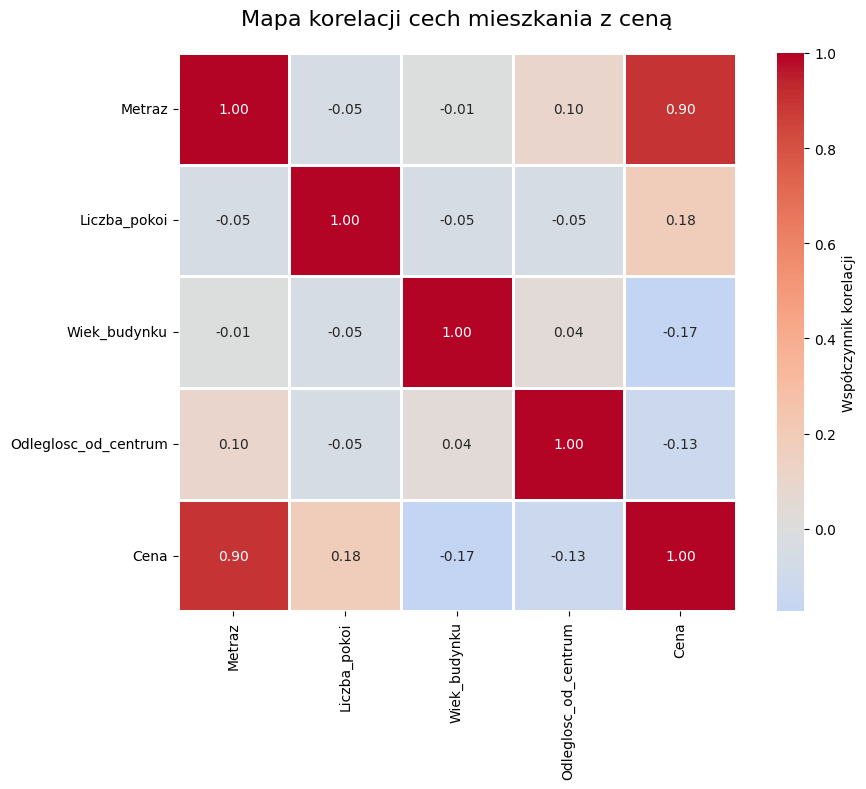

In [35]:
# Rysowanie mapy ciepła (heatmap) korelacji
plt.figure(figsize=(10, 8))
sns.heatmap(
    korelacje,
    annot=True,           # Wyświetlanie wartości korelacji na mapie
    cmap='coolwarm',      # Paleta kolorów (czerwony=dodatnia, niebieski=ujemna)
    center=0,             # Centrowanie skali na 0
    fmt='.2f',            # Format liczb (2 miejsca po przecinku)
    square=True,          # Kwadratowe komórki
    linewidths=1,         # Grubość linii między komórkami
    cbar_kws={'label': 'Współczynnik korelacji'}
  )
plt.title('Mapa korelacji cech mieszkania z ceną', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

In [37]:
# Dodatkowa analiza: korelacja z ceną
print("Korelacja poszczególnych cech z ceną:")
print(korelacje['Cena'].sort_values(ascending=False).round(3))

Korelacja poszczególnych cech z ceną:
Cena                    1.000
Metraz                  0.903
Liczba_pokoi            0.176
Odleglosc_od_centrum   -0.131
Wiek_budynku           -0.173
Name: Cena, dtype: float64


In [38]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# 1. Podział na cechy (X) i zmienną docelową (y)
X = df.drop(columns=['Cena'])
y = df['Cena']

# 2. Podział na zbiór treningowy (80%) i testowy (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Trening modelu Regresji Liniowej
model = LinearRegression()
model.fit(X_train, y_train)

# 4. Predykcja na danych testowych
y_pred = model.predict(X_test)

# 5. Obliczenie błędu MAE
mae = mean_absolute_error(y_test, y_pred)
print(f"Średni błąd modelu to: {mae:,.0f} zł")

# 6. Współczynniki modelu dla każdej cechy
print("\nWspółczynniki modelu (wpływ na cenę):")
for cecha, wspolczynnik in zip(X.columns, model.coef_):
    print(f"  {cecha:25s}: {wspolczynnik:>10,.0f} zł")

Średni błąd modelu to: 42,050 zł

Współczynniki modelu (wpływ na cenę):
  Metraz                   :      5,028 zł
  Liczba_pokoi             :     28,325 zł
  Wiek_budynku             :     -1,925 zł
  Odleglosc_od_centrum     :     -7,919 zł


In [39]:
def wycen_mieszkanie(metraz, liczba_pokoi, wiek_budynku, odleglosc_od_centrum):
    """Wycenia mieszkanie na podstawie jego cech."""
    dane = pd.DataFrame([[metraz, liczba_pokoi, wiek_budynku, odleglosc_od_centrum]],
                        columns=['Metraz', 'Liczba_pokoi', 'Wiek_budynku', 'Odleglosc_od_centrum'])
    cena = model.predict(dane)[0]
    print(f"Szacowana wycena mieszkania: {cena:,.0f} zł")
    return cena

# Mieszkanie marzeń: 65 m², 3 pokoje, 5 lat, 2 km od centrum
wycen_mieszkanie(metraz=65, liczba_pokoi=3, wiek_budynku=5, odleglosc_od_centrum=2)

Szacowana wycena mieszkania: 388,356 zł


np.float64(388356.27646071714)